# Protein Matrix Pipeline

Pipeline: **1. EDA** → **2. Build AnnData** → **3. Binary slot** (background + threshold) → **4. Save H5AD**

**Notebook structure:** Setup → Extract Data → **1. EDA** (intensity, cell area) → **2. Build + 3. Binary + 4. Save** → Sanity Check

Output: `X` = continuous intensities, `layers["binary"]` = binarized 0/1 for cell typing.

---

## Data paths

| Source | Input | Description |
|--------|-------|-------------|
| **Zarr** | `data/CellDIVE_SLIDE-045.zarr` | 23-channel CellDIVE multiplexed image |
| **Zarr** | `output/cellpose_output/cellpose_masks_dapi_only_9tiles.zarr` | DAPI-only Cellpose segmentation masks |
| **CSV** | `input/analysis/cell_data.csv` or `output/cellpose_output/cell_intensities.csv` | Pre-computed per-cell intensities |

---

## EDA (Section 1)

| Step | Purpose |
|------|--------|
| Intensity (log scale, positive only) | Primary view for threshold choice |
| Cell area | Optional: inspect segmentation size distribution |

---

## Two extraction paths

1. **Extract from zarr + mask** (`DATA_SOURCE = "zarr"`) — Measure per-cell mean intensity for each protein channel from CellDIVE zarr and Cellpose masks.
2. **Convert from CSV** (`DATA_SOURCE = "csv"`) — Build H5AD from existing CSV (e.g. `cell_data.csv` from PIPEX or `cell_intensities.csv` from `measure_cell_intensities.py`).

---

## Output

**File:** `output/celldive_protein_matrix.h5ad`

| AnnData slot | Description |
|--------------|-------------|
| `X` | Continuous intensities (float32) |
| `layers["binary"]` | Binarized 0/1 for cell typing |
| `obs` | cell_id, area, centroid_x, centroid_y |
| `var` | Protein names |
| `obsm["spatial"]` | Centroids (x, y) |
| `uns` | sample_id, data_source, binary_threshold, binary_thresholds, background_estimate |

## Imports

In [1]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import zarr
from pathlib import Path
from skimage.measure import regionprops
from tqdm.auto import tqdm

import anndata as ad

# Optional: GPU acceleration (CuPy). Falls back to vectorized NumPy if unavailable.
try:
    import cupy as cp
    HAS_CUPY = True
    print("CuPy version:", cp.__version__)
except ImportError:
    HAS_CUPY = False
    print("CuPy not installed. Vectorized NumPy will be used.")

# Optional: for downstream analysis
# import scanpy as sc

CuPy version: 14.0.1


## Configuration

| Variable | Default | Description |
|----------|---------|-------------|
| `PROJECT_ROOT` | Auto-detected | Project root (parent of `notebooks/` when run from there) |
| `CELLDIVE_ZARR` | `data/CellDIVE_SLIDE-045.zarr` | 23-channel CellDIVE image |
| `MASK_ZARR` | `output/cellpose_output/cellpose_masks_dapi_only_9tiles.zarr` | DAPI-only Cellpose masks |
| `OUTPUT_H5AD` | `output/celldive_protein_matrix.h5ad` | Output H5AD path |
| `CELL_DATA_CSV` | `input/analysis/cell_data.csv` | PIPEX cell measurements (optional) |
| `CELL_INTENSITIES_CSV` | `output/cellpose_output/cell_intensities.csv` | measure_cell_intensities output (optional) |
| `DATA_SOURCE` | `"zarr"` | `"zarr"` = extract from zarr+mask; `"csv"` = convert from CSV |
| `TILE_SIZE` | `16384` | Tile size. With 128 GB RAM, 16384–32768 is fine |
| `USE_GPU` | `True` | CuPy+CUDA for bincount (NVIDIA only). Falls back to CPU if unavailable |
| `GATING_CSV` | `output/gating_thresholds.csv` | Per-marker thresholds from `determine_binary_threshold.ipynb`. If present, used for `layers["binary"]`; otherwise falls back to p25. |

In [2]:
# Paths: project root is parent of cwd when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print(f"Project root: {PROJECT_ROOT}")

# Zarr inputs (data/ and output/ are under project root)
CELLDIVE_ZARR = PROJECT_ROOT / "data" / "CellDIVE_SLIDE-045.zarr"
MASK_ZARR = PROJECT_ROOT / "output" / "cellpose_output" / "cellpose_masks_dapi_only_9tiles.zarr"
OUTPUT_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix.h5ad"
print(f"Output H5AD: {OUTPUT_H5AD}")
print(f"CELLDIVE_ZARR: {CELLDIVE_ZARR}")
print(f"MASK_ZARR: {MASK_ZARR}")

# Alternative: CSV path (if you already have per-cell measurements)
CELL_DATA_CSV = PROJECT_ROOT / "input" / "analysis" / "cell_data.csv"
CELL_INTENSITIES_CSV = PROJECT_ROOT / "output" / "cellpose_output" / "cell_intensities.csv"
print(f"CELL_DATA_CSV: {CELL_DATA_CSV}")
print(f"CELL_INTENSITIES_CSV: {CELL_INTENSITIES_CSV}")

# Which path to use: "zarr" or "csv"
DATA_SOURCE = "zarr"  # Change to "csv" if using existing CSV

# Tile size for zarr extraction. With 128 GB RAM: 16384 (~4 GB/tile), 32768 (~16 GB/tile) are fine.
TILE_SIZE = 32768

# Use GPU (CuPy+CUDA) for bincount. Requires NVIDIA GPU (not Apple Silicon). Falls back to CPU if unavailable.
USE_GPU = True

# Per-marker thresholds produced by determine_binary_threshold.ipynb.
# If the CSV exists, each marker gets its own threshold; otherwise falls back to global p25.
GATING_CSV = PROJECT_ROOT / "output" / "gating_thresholds.csv"

Project root: /home/steve/Projects/HeLab/BladderDIVE
Output H5AD: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix.h5ad
CELLDIVE_ZARR: /home/steve/Projects/HeLab/BladderDIVE/data/CellDIVE_SLIDE-045.zarr
MASK_ZARR: /home/steve/Projects/HeLab/BladderDIVE/output/cellpose_output/cellpose_masks_dapi_only_9tiles.zarr
CELL_DATA_CSV: /home/steve/Projects/HeLab/BladderDIVE/input/analysis/cell_data.csv
CELL_INTENSITIES_CSV: /home/steve/Projects/HeLab/BladderDIVE/output/cellpose_output/cell_intensities.csv


## Get Channel Names from CellDIVE Zarr

**Returns:** `list[str] | None` — Short protein names (e.g. `["DAPI", "CD45", "CD3E", ...]`), or `None` if `.zattrs` is missing.

In [3]:
def get_channel_names(zarr_path: Path) -> list[str] | None:
    """
    Read channel labels from CellDIVE zarr .zattrs and map to short protein names.

    Returns
    -------
    list[str] | None
        Short names (e.g. DAPI, CD45, CD3E, PANCK) in channel order, or None if
        .zattrs is missing or has no omero channel metadata.
    """
    zattrs_path = zarr_path / ".zattrs"
    if not zattrs_path.exists():
        return None
    with open(zattrs_path) as f:
        meta = json.load(f)
    channels_meta = meta.get("omero", {}).get("channels", [])
    if not channels_meta and "multiscales" in meta:
        channels_meta = meta["multiscales"][0].get("omero", {}).get("channels", [])
    if not channels_meta:
        return None
    # Map full labels to short names
    ALIAS = {
        "DAPI_AF_R01": "DAPI", "DAPI_R06": "DAPI2",
        "CD45-AF488-CST": "CD45", "CD3E-AF555-CST": "CD3E", "CD8a-AF750-CST": "CD8a",
        "Ki67-AF647-CST": "Ki67", "Vim-AF488-CST": "VIM", "CD68-AF555-CST": "CD68",
        "HLA-DRA-AF4647": "HLADR", "CD31-AF750": "CD31", "SMA-AF488": "ACTA2",
        "CD20-AF555": "CD20", "CD163-AF647": "CD163", "CD44-AF750-Nov": "CD44",
        "PanCK-AF488": "PANCK", "CD38-AF555": "CD38", "CD11c-AF647": "CD11c",
        "PDGFRA-AF488": "PDGFRA", "COL1A1-AF555": "COL1A1", "CD14-AF647": "CD14",
        "EPCAM-AF488": "EPCAM", "CD56-AF555": "CD56", "CD45RO-AF647-BioT": "CD45RO",
    }
    names = []
    for ch in channels_meta:
        label = ch.get("label", "")
        names.append(ALIAS.get(label, label))
    return names

## Extract from Zarr + Mask

**Returns:** `tuple[X, obs, var_names]`

| Return | Type | Description |
|--------|------|-------------|
| `X` | `np.ndarray` (n_cells, n_channels) | Per-cell mean intensity per channel (float32) |
| `obs` | `pd.DataFrame` | Columns: `cell_id`, `area`, `centroid_y`, `centroid_x` |
| `var_names` | `list[str]` | Protein channel names (e.g. DAPI, CD45, CD3E) |

In [4]:
# Import memory-safe tile-based extraction (avoids loading full image into RAM)
import sys
import importlib
sys.path.insert(0, str(PROJECT_ROOT))
import scripts.extract_protein_matrix_tiled as _extract_mod
importlib.reload(_extract_mod)  # ensure latest version after script edits
from scripts.extract_protein_matrix_tiled import extract_protein_matrix_from_zarr


## Convert from CSV

**Returns:** `tuple[X, obs, var_names]`

| Return | Type | Description |
|--------|------|-------------|
| `X` | `np.ndarray` (n_cells, n_proteins) | Intensity values from CSV columns (float32) |
| `obs` | `pd.DataFrame` | Cell metadata (cell_id, centroid_x/y or X/Y, area if present) |
| `var_names` | `list[str]` | Protein names parsed from column headers |

In [5]:
def build_from_csv(
    csv_path: Path,
    intensity_col_pattern: str = "_mean",
    id_col: str = "cell_id",
    x_col: str | None = "centroid_x",
    y_col: str | None = "centroid_y",
) -> tuple[np.ndarray, pd.DataFrame, list[str]]:
    """
    Build matrix from CSV. Handles:
    - cell_intensities.csv: CD45_mean, CD3E_mean, CD8a_mean
    - cell_data.csv (PIPEX): DAPI, CD45, CD3E, ... (no _mean suffix)
    """
    df = pd.read_csv(csv_path)
    # Find intensity columns
    if intensity_col_pattern:
        intensity_cols = [c for c in df.columns if c.endswith(intensity_col_pattern)]
        var_names = [c.replace(intensity_col_pattern, "") for c in intensity_cols]
    else:
        # PIPEX cell_data.csv: columns like DAPI, CD45, CD3E (exclude ID, coords, metadata)
        exclude = {id_col, "CellID", "X", "Y", "centroid_x", "centroid_y", "area",
                   "Cluster", "Neighbors", "LocalDensity"}
        exclude |= {c for c in df.columns if "_norm" in c or c.endswith("_positive")}
        intensity_cols = [c for c in df.columns if c not in exclude
                         and df[c].dtype in (np.float64, np.float32, np.int64, np.int32)]
        var_names = intensity_cols.copy()

    if not intensity_cols:
        raise ValueError(f"No intensity columns found. Try intensity_col_pattern='_mean' or ''")

    X = df[intensity_cols].values.astype(np.float32)
    obs_cols = [id_col] if id_col in df.columns else ["CellID"] if "CellID" in df.columns else []
    for col in [x_col, y_col, "area", "X", "Y"]:
        if col and col in df.columns and col not in obs_cols:
            obs_cols.append(col)
    obs = df[[c for c in obs_cols if c in df.columns]].copy()
    obs = obs.rename(columns={"CellID": "cell_id", "X": "centroid_x", "Y": "centroid_y"})
    return X, obs, var_names

## Extract Data (or load from CSV)

Loads data via `DATA_SOURCE`. Output: `X`, `obs`, `var_names`.

In [6]:
t0 = time.perf_counter()
if DATA_SOURCE == "zarr":
    if not CELLDIVE_ZARR.exists():
        raise FileNotFoundError(f"CellDIVE zarr not found: {CELLDIVE_ZARR}")
    if not MASK_ZARR.exists():
        raise FileNotFoundError(f"Mask zarr not found: {MASK_ZARR}")
    channel_names = get_channel_names(CELLDIVE_ZARR)
    X, obs, var_names = extract_protein_matrix_from_zarr(
        CELLDIVE_ZARR, MASK_ZARR, channel_names, tile_size=TILE_SIZE, use_gpu=USE_GPU
    )
else:
    # Try cell_data.csv first, then cell_intensities.csv
    csv_path = CELL_DATA_CSV if CELL_DATA_CSV.exists() else CELL_INTENSITIES_CSV
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found. Tried: {CELL_DATA_CSV}, {CELL_INTENSITIES_CSV}")
    # PIPEX cell_data has raw columns; cell_intensities has _mean
    pattern = "_mean" if "intensities" in str(csv_path) else ""
    X, obs, var_names = build_from_csv(csv_path, intensity_col_pattern=pattern)

print(f"Matrix shape: {X.shape} (cells × proteins)")
print(f"Proteins: {var_names}")
print(f"Cell elapsed: {time.perf_counter()-t0:.1f}s", flush=True)

Using GPU (CuPy) for bincount
[1/5] Scanning mask for max label...
      max_label=926,005 in 9.1s
[2/5] Accumulating geometry (counts, centroids)...
[3/5] Extracting intensities per channel...
      tiles 6/6...
[4/5] Building obs and X...
[5/5] Done. 926,006 cells in 1919.0s
Matrix shape: (926006, 23) (cells × proteins)
Proteins: ['DAPI', 'CD45', 'CD3E', 'Ki67', 'CD8a', 'VIM', 'CD68', 'HLADR', 'CD31', 'ACTA2', 'CD20', 'CD163', 'CD44', 'PANCK', 'CD38', 'CD11c', 'PDGFRA', 'COL1A1', 'CD14', 'EPCAM', 'CD56', 'CD45RO', 'DAPI2']
Cell elapsed: 1919.1s


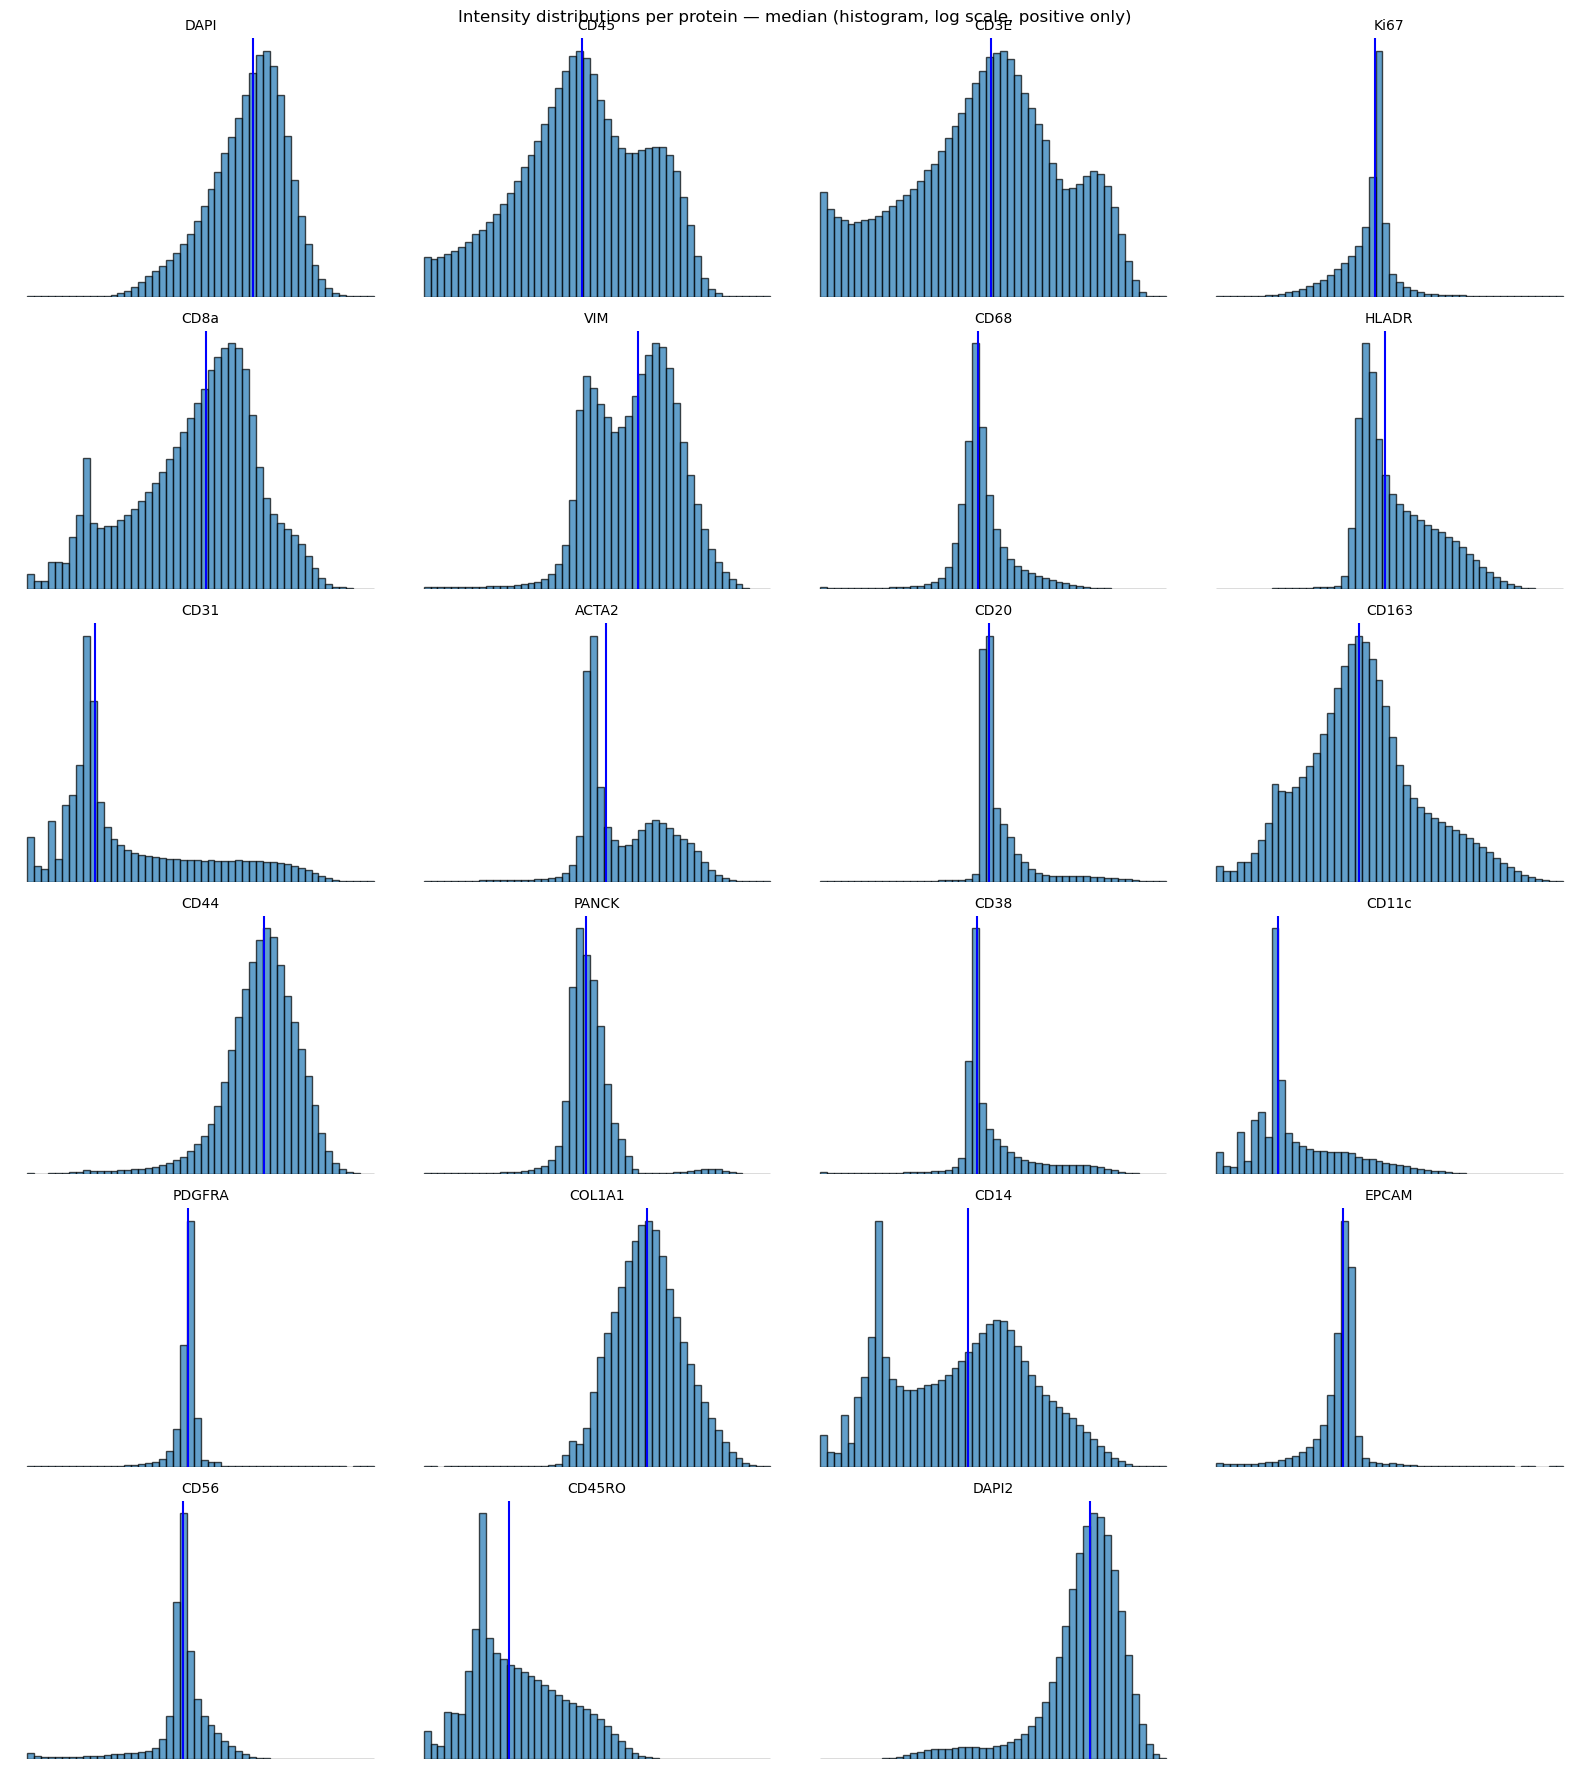

In [7]:
# Intensity distributions with median (log scale, positive only)
n_proteins = X.shape[1]
n_cols = min(4, n_proteins)
n_rows = (n_proteins + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_2d(axes)
for i, ax in enumerate(axes.flat):
    if i < n_proteins:
        vals = X[:, i]
        vals = vals[vals > 0]
        log_vals = np.log10(vals + 1)
        ax.hist(log_vals, bins=50, edgecolor="k", alpha=0.7)
        if len(log_vals) > 0:
            ax.axvline(np.median(log_vals), color="blue", linestyle="-", linewidth=1.5, label="median")
        ax.set_title(var_names[i], fontsize=10)
        ax.set_xlabel("log10(intensity + 1)")
    ax.axis("off")
plt.suptitle("Intensity distributions per protein — median (histogram, log scale, positive only)", fontsize=12)
plt.tight_layout()
plt.show()

### Reading the histograms

Histograms use the **same log transform and positive-only rule** as the violins. The **median** line is a **robust** central tendency for skewed fluorescence.

- **Shifted right** vs other channels: generally **brighter** overall (after extraction).
- **Very peaked near zero** (on the log axis): most positives are still **low**; thresholds matter.
- Compare channels that should be **mutually exclusive** (e.g. immune vs epitope) for **unexpected overlap** in the upper tails.

These plots do **not** replace QC on **segmentation** (see cell area plot) or **registration**—they summarize **what landed in `X`**.


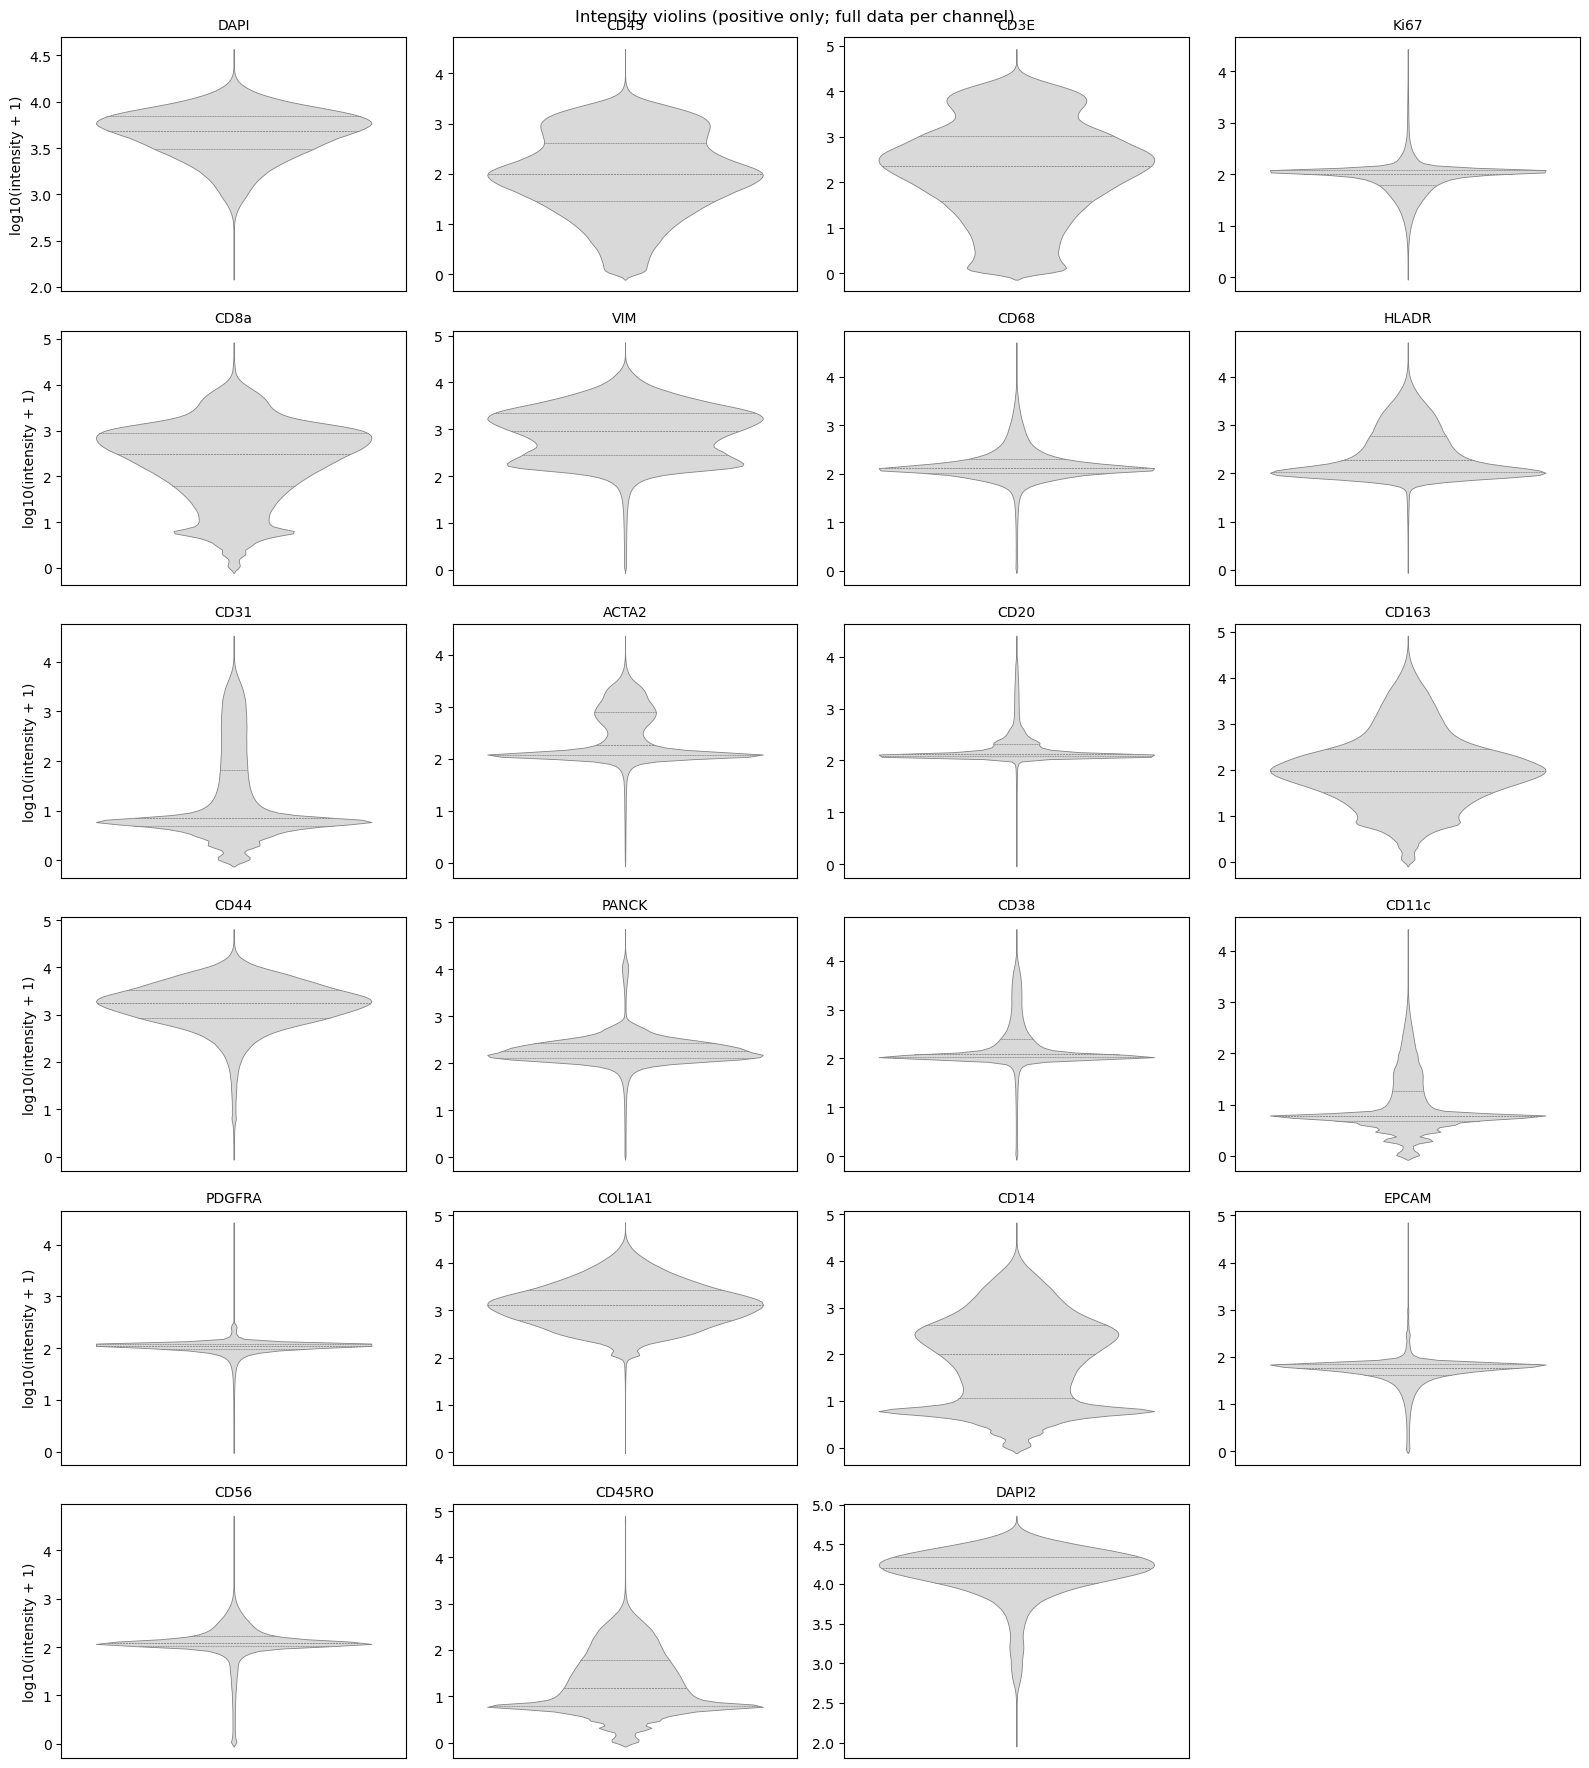

In [8]:
# Violin plots (KDE-shaped body; inner lines = quartiles) — same log scale, positive only
# Uses all positive cells per channel (no subsampling); reintroduce a cap if KDE becomes slow.

n_proteins = X.shape[1]
n_cols = min(4, n_proteins)
n_rows = (n_proteins + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_2d(axes)
for i, ax in enumerate(axes.flat):
    if i < n_proteins:
        vals = X[:, i]
        vals = vals[vals > 0]
        log_vals = np.log10(vals + 1)
        if len(log_vals) > 0:
            sns.violinplot(y=log_vals, ax=ax, inner="quartile", color="0.85", linewidth=0.6)
        ax.set_title(var_names[i], fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("log10(intensity + 1)" if i % n_cols == 0 else "")
        ax.set_xticks([])
    else:
        ax.axis("off")
plt.suptitle("Intensity violins (positive only; full data per channel)", fontsize=12)
plt.tight_layout()
plt.show()


### Reading the violin panels

Violins summarize **only cells with strictly positive intensity** in that channel (zeros dropped), on **log₁₀(intensity + 1)**. That emphasizes the **active** population and avoids a tall spike at zero.

- **Wide body**: many cells span that intensity range.
- **Long upper whisker / thick upper quartile**: a tail of **bright** cells (potential positives or spillover—compare to biology and neighbors).
- **Narrow violin near the floor**: most positive cells are dim; check histograms for whether the channel is **weak** or **mostly background**.

Use these together with **`uns['binary_threshold']` / layers `binary`** (later in the notebook) to see how continuous signal was turned into calls.


### Interpreting violins & cutoffs

**Axes** — Each panel is **log₁₀(intensity + 1)** for that protein, **only cells with intensity > 0** in that channel. Zeros are dropped so the plot reflects the **positive** mass (background-only cells for that marker disappear from this view for that channel).

**What the drawing means** — The gray envelope is a **KDE** (smoothed density). The three **inner dashed lines** are **quartiles** (Q1, median, Q3), not hard cutoffs.

**Bimodal violins** (two bulges or a clear “waist”, e.g. CD45, CD3E, CD8a, CD163, CD14, VIM, ACTA2, HLADR, PANCK, CD31, CD11c, CD45RO) — Often **low cluster ≈ “negative”** and **upper cluster ≈ “positive”** for that marker. A practical cutoff is near the **minimum between the two modes** on this log axis (or slightly into the upper bump to be conservative). In **linear** space: if your plotted value is `t = log10(x+1)`, then `x = 10**t - 1` (same units as matrix `X`).

**Unimodal / tight violins** (one dominant peak, e.g. DAPI, DAPI2, PDGFRA, CD56, CD20, CD38) — No obvious negative/positive split from shape alone; use a **fixed percentile rule** (reproducible) or expert/manual gates.

**Cutoffs in *this* notebook** — The **Build + Binary** step reads per-marker thresholds from `output/gating_thresholds.csv` (produced by `determine_binary_threshold.ipynb`). Each marker gets its own threshold calibrated to its distribution (Otsu or GMM). Results appear in `uns["binary_thresholds"]` (linear scale) and in the sorted table (**threshold**, **n_cells_with_protein**). If the CSV is missing, falls back to global p25 per marker.

**How to tune** — (1) Run `determine_binary_threshold.ipynb`, inspect the per-marker histograms, apply manual overrides if needed, then save `gating_thresholds.csv`. (2) Re-run this notebook to rebuild the H5AD with the improved thresholds. (3) Validate a few proteins in napari/ImageJ against tissue expectations.


## 1. Exploratory Data Analysis

**Intensity distributions** — Histograms (median) and violins (`inner="quartile"`) on log₁₀(intensity+1), **positive only** (all cells per channel in violins unless you add a subsample cap).

**Cell area** — Inspect area distribution (optional context for segmentation quality).

### Cell area — optional inspection

Area percentiles help interpret segmentation scale (optional; not used in the build step below).

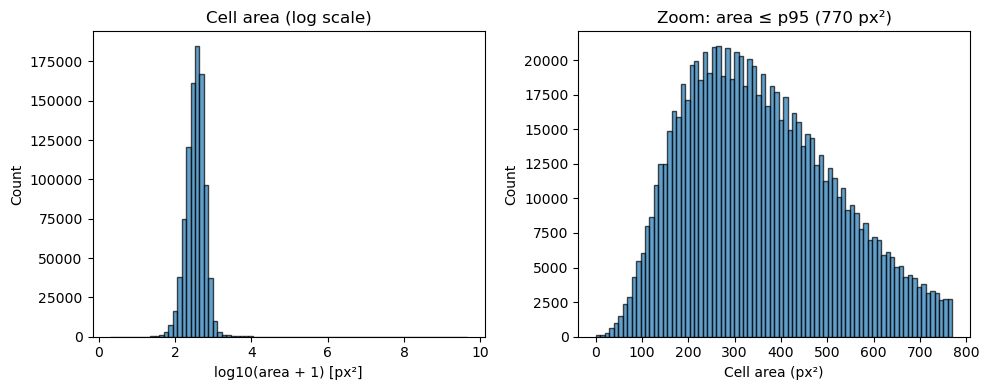

Area percentiles (px²):
  p1: 79
  p5: 130
  p10: 165
  p25: 238
  p50: 351
  p75: 493
  p90: 649
  p95: 770
  p99: 1156


In [9]:
if "area" in obs.columns:
    areas = obs["area"].values
    areas_pos = areas[areas > 0]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(np.log10(areas_pos + 1), bins=80, edgecolor="k", alpha=0.7)
    axes[0].set_xlabel("log10(area + 1) [px²]")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Cell area (log scale)")
    p95 = np.percentile(areas, 95)
    zoom = areas[areas <= p95]
    axes[1].hist(zoom, bins=80, edgecolor="k", alpha=0.7)
    axes[1].set_xlabel("Cell area (px²)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Zoom: area ≤ p95 ({p95:.0f} px²)")
    plt.tight_layout()
    plt.show()
    pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    vals = [np.percentile(areas, p) for p in pcts]
    print("Area percentiles (px²):")
    for p, v in zip(pcts, vals):
        print(f"  p{p}: {v:.0f}")

### Reading the cell area plot

**Area** is in **pixel²** of the mask used for extraction (scale matches your segmentation). The distribution tells you whether cells are **comparable in size** or whether a long tail of **huge** or **tiny** objects suggests merges, fragments, or debris.

This is **diagnostic** for interpreting intensities (integrated signal scales with area unless you normalize elsewhere). It is **not** used automatically in the binary/threshold step unless you add that logic.


In [10]:
# EDA summary
print(f"n_cells: {X.shape[0]}, n_proteins: {X.shape[1]}")
print(f"Intensity ranges: min={X.min():.2f}, max={X.max():.2f}")

n_cells: 926006, n_proteins: 23
Intensity ranges: min=0.00, max=65534.00


### EDA → build: what to verify before `AnnData`

- **Counts**: `n_cells` / `n_proteins` match expectations for the ROI or export.
- **Histograms / violins**: no channel is **dead** or **saturated everywhere** without explanation.
- **Area**: no dominant mode at **absurdly small** area (specks) unless you expect single-pixel artifacts.

If those look reasonable, the continuous matrix **`X`** and later **`binary`** layer are trustworthy enough for downstream SpatialData / clustering; if not, fix **extraction, mask, or thresholds** before saving H5AD.


## 2. Build AnnData, 3. Binary Slot, 4. Save H5AD

Implements pipeline steps 2–4: build AnnData with **X** = continuous intensities (float32), add **layers["binary"]**, save.

- **X** = continuous intensities (float32), never overwritten
- **layers["binary"]** = binarized 0/1 for cell typing
- **3a:** Background estimate (p10 of **positive** intensities per channel) → `uns["background_estimate"]`
- **3b:** Percentile thresholds (**positive** intensities per channel) → `layers["binary"]`, `uns["binary_threshold"]`, `uns["binary_thresholds"]`

In [11]:
# Build AnnData with X = continuous intensities (float32)
X_float = X.astype(np.float32) if X.dtype != np.float32 else X
adata = ad.AnnData(X=X_float, obs=obs.copy(), var=pd.DataFrame(index=var_names))
adata.obs_names = [str(i) for i in adata.obs["cell_id"]]
adata.var_names = list(var_names)

# obsm and uns
if "centroid_x" in adata.obs.columns and "centroid_y" in adata.obs.columns:
    adata.obsm["spatial"] = adata.obs[["centroid_x", "centroid_y"]].values
elif "X" in adata.obs.columns and "Y" in adata.obs.columns:
    adata.obsm["spatial"] = adata.obs[["X", "Y"]].values
adata.uns["sample_id"] = "CellDIVE_SLIDE-045"
adata.uns["data_source"] = DATA_SOURCE

def _percentile_positive_cols(X, q):
    """Per-column percentile over values > 0; columns with no positives → 0."""
    X = np.asarray(X)
    out = np.zeros(X.shape[1], dtype=np.float64)
    for j in range(X.shape[1]):
        col = X[:, j]
        pos = col[col > 0]
        if pos.size:
            out[j] = np.percentile(pos, q)
    return out


# --- 3a. Background (p10 of positive intensities per channel) ---
BG_PERCENTILE = 10
adata.uns["background_percentile"] = BG_PERCENTILE
adata.uns["background_estimate"] = dict(
    zip(adata.var_names, _percentile_positive_cols(adata.X, BG_PERCENTILE).tolist())
)

# --- 3b. Per-marker binary thresholds and layers["binary"] ---
# DAPI/DAPI2: not gated (Cellpose DAPI masks define cells). Binary column set to 1 for all cells.
SKIP_BINARY_MARKERS = {"DAPI", "DAPI2"}

# Load per-marker thresholds from gating_thresholds.csv (produced by determine_binary_threshold.ipynb).
# Falls back to global p25 of positive intensities per marker if the CSV is missing.
if GATING_CSV.exists():
    gating_df = pd.read_csv(GATING_CSV).set_index("marker")
    thresholds = np.array([
        np.nan if m in SKIP_BINARY_MARKERS
        else float(gating_df.loc[m, "threshold"]) if m in gating_df.index
        else float(np.percentile(adata.X[:, j][adata.X[:, j] > 0], 25))
              if (adata.X[:, j] > 0).any() else 0.0
        for j, m in enumerate(adata.var_names)
    ])
    threshold_source = f"gating_thresholds.csv (per-marker, {len(gating_df)} markers)"
    print(f"Loaded per-marker thresholds from {GATING_CSV.name}")
    missing = [m for m in adata.var_names if m not in gating_df.index and m not in SKIP_BINARY_MARKERS]
    if missing:
        print(f"  Markers not in CSV (used p25 fallback): {missing}")
else:
    print(f"WARNING: {GATING_CSV.name} not found — falling back to global p25 per marker.")
    print("  Run determine_binary_threshold.ipynb first for biologically meaningful thresholds.")
    thresholds = np.array([
        np.nan if m in SKIP_BINARY_MARKERS
        else _percentile_positive_cols(adata.X, 25)[j]
        for j, m in enumerate(adata.var_names)
    ])
    threshold_source = "p25 fallback (run determine_binary_threshold.ipynb)"

adata.uns["binary_threshold"] = threshold_source
adata.uns["binary_thresholds"] = dict(zip(adata.var_names, thresholds.tolist()))

# Comparison table (p25 / p75 / p90 / chosen threshold)
p25_vals = _percentile_positive_cols(adata.X, 25)
p50_vals = _percentile_positive_cols(adata.X, 50)
p75_vals = _percentile_positive_cols(adata.X, 75)
p90_vals = _percentile_positive_cols(adata.X, 90)
n_cells_with_protein = np.array([
    adata.n_obs if m in SKIP_BINARY_MARKERS or not np.isfinite(thresholds[j])
    else int((adata.X[:, j] >= thresholds[j]).sum())
    for j, m in enumerate(adata.var_names)
])
th_df = pd.DataFrame({
    "protein": adata.var_names,
    "p25": np.round(p25_vals, 2), "p50": np.round(p50_vals, 2),
    "p75": np.round(p75_vals, 2), "p90": np.round(p90_vals, 2),
    "threshold": thresholds, "n_cells_with_protein": n_cells_with_protein,
})
print(f"\nBinary thresholds — source: {threshold_source}")
display(th_df.sort_values("threshold").reset_index(drop=True))

# layers["binary"] — do NOT overwrite X
binary = np.zeros_like(adata.X, dtype=np.uint8)
for j, m in enumerate(adata.var_names):
    if m in SKIP_BINARY_MARKERS:
        binary[:, j] = 1  # all mask cells are nucleus-positive by definition
    else:
        binary[:, j] = (adata.X[:, j] >= thresholds[j]).astype(np.uint8)
adata.layers["binary"] = binary

# Save single H5AD (X continuous + layers["binary"])
OUTPUT_H5AD.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(OUTPUT_H5AD)
print(f"Saved: {OUTPUT_H5AD}")
adata


/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Loaded per-marker thresholds from gating_thresholds.csv

Binary thresholds — source: gating_thresholds.csv (per-marker, 21 markers)


,protein,p25,p50,p75,p90,threshold,n_cells_with_protein
0,CD11c,3.89,5.06,17.88,75.38,60.0,103436
1,EPCAM,41.03,57.44,68.59,78.51,78.5,91715
2,CD31,4.01,6.26,65.80,735.69,80.0,212207
3,CD45RO,5.10,14.39,58.74,189.41,100.0,159748
4,CD14,10.28,100.74,411.72,1405.36,100.0,457545
5,PDGFRA,95.82,110.68,121.53,132.14,132.1,92460
6,Ki67,59.80,101.02,119.43,147.13,147.1,92649
7,CD56,102.36,122.71,167.97,298.81,200.0,173406
8,HLADR,105.45,183.95,602.13,1708.96,217.2,421535
9,CD20,120.76,133.43,206.51,426.67,300.0,134943


Saved: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix.h5ad


AnnData object with n_obs × n_vars = 926006 × 23
    obs: 'cell_id', 'area', 'centroid_x', 'centroid_y'
    uns: 'sample_id', 'data_source', 'background_percentile', 'background_estimate', 'binary_threshold', 'binary_thresholds'
    obsm: 'spatial'
    layers: 'binary'

In [12]:
print(adata.uns)
print(adata.uns['data_source'])

OrderedDict([('sample_id', 'CellDIVE_SLIDE-045'), ('data_source', 'zarr'), ('background_percentile', 10), ('background_estimate', {'DAPI': 1865.61328125, 'CD45': 6.62294864654541, 'CD3E': 4.166666507720947, 'Ki67': 28.61693572998047, 'CD8a': 8.385640144348145, 'VIM': 151.7564239501953, 'CD68': 71.15021514892578, 'HLADR': 82.05352783203125, 'CD31': 2.0, 'ACTA2': 100.07183074951172, 'CD20': 113.85623931884766, 'CD163': 8.537176132202148, 'CD44': 399.64764404296875, 'PANCK': 100.31954193115234, 'CD38': 90.86872863769531, 'CD11c': 1.9158563613891602, 'PDGFRA': 74.71781158447266, 'COL1A1': 328.3622131347656, 'CD14': 4.018355369567871, 'EPCAM': 20.922883987426758, 'CD56': 61.00773620605469, 'CD45RO': 2.966809034347534, 'DAPI2': 5615.67578125}), ('binary_threshold', 'gating_thresholds.csv (per-marker, 21 markers)'), ('binary_thresholds', {'DAPI': nan, 'CD45': 494.8, 'CD3E': 655.6, 'Ki67': 147.1, 'CD8a': 600.0, 'VIM': 2351.2, 'CD68': 436.0, 'HLADR': 217.2, 'CD31': 80.0, 'ACTA2': 472.2, 'CD20':

## Sanity Check

In [13]:
# Reload and inspect
adata_check = ad.read_h5ad(OUTPUT_H5AD)
print("AnnData structure:")
print(f"  X: {adata_check.X.shape} (cells × proteins, continuous)")
if "binary" in adata_check.layers:
    print(f"  layers['binary']: {adata_check.layers['binary'].shape}")
print(f"  obs: {list(adata_check.obs.columns)}")
print(f"  var: {list(adata_check.var_names)}")
if "spatial" in adata_check.obsm:
    print(f"  obsm['spatial']: {adata_check.obsm['spatial'].shape}")
print("\nFirst few cells - X (continuous):")
print(adata_check.X[:5, :5])
if "binary" in adata_check.layers:
    print("\nFirst few cells - layers['binary']:")
    print(adata_check.layers["binary"][:5, :5])

AnnData structure:
  X: (926006, 23) (cells × proteins, continuous)
  layers['binary']: (926006, 23)
  obs: ['cell_id', 'area', 'centroid_x', 'centroid_y']
  var: ['DAPI', 'CD45', 'CD3E', 'Ki67', 'CD8a', 'VIM', 'CD68', 'HLADR', 'CD31', 'ACTA2', 'CD20', 'CD163', 'CD44', 'PANCK', 'CD38', 'CD11c', 'PDGFRA', 'COL1A1', 'CD14', 'EPCAM', 'CD56', 'CD45RO', 'DAPI2']
  obsm['spatial']: (926006, 2)

First few cells - X (continuous):
[[8.8636194e+02 9.4710548e+01 1.2563584e+02 4.5948185e+01 7.5435135e+01]
 [7.0096045e+03 5.7742444e+02 5.5769783e+01 1.0959712e+02 2.8933093e+02]
 [6.8788740e+03 8.4655725e+02 5.4288550e+02 7.9980919e+01 5.7545803e+01]
 [8.7082776e+02 1.6562885e+02 0.0000000e+00 6.9317924e+01 1.9173670e+00]
 [1.0258480e+04 1.8356714e+03 3.4785713e+01 1.3564285e+02 2.5628571e+01]]

First few cells - layers['binary']:
[[1 0 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]
 [1 0 0 0 0]
 [1 1 0 0 0]]
